# Exercícios — Dados Desbalanceados

**Tema:** Preparação de Dados › Dados Desbalanceados

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    confusion_matrix, precision_recall_curve,
)
from sklearn.dummy import DummyClassifier

rng = np.random.default_rng(135)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("ambiente pronto")

ambiente pronto


---
## Dataset de trabalho: detecção de churn (2% de taxa de cancelamento)

In [2]:
n = 6000
taxa_churn = 0.02
n_churn = int(n * taxa_churn)
n_ficou = n - n_churn

engajamento_ficou = rng.normal(70, 15, n_ficou)
engajamento_churn = rng.normal(25, 15, n_churn)
X = np.concatenate([engajamento_ficou, engajamento_churn]).reshape(-1, 1)
y = np.concatenate([np.zeros(n_ficou), np.ones(n_churn)])
ordem = rng.permutation(n)
X, y = X[ordem], y[ordem]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0)
print(f"treino: {len(y_treino)} ({y_treino.mean():.2%} churn)")
print(f"teste : {len(y_teste)} ({y_teste.mean():.2%} churn)")

treino: 4200 (2.00% churn)
teste : 1800 (2.00% churn)


---
## Exercício 1 🟢 — O baseline burro e a acurácia enganosa

Treine um `DummyClassifier(strategy="most_frequent")`. Reporte acurácia,
precisão e recall. Depois treine uma `LogisticRegression` simples (sem
nenhuma correção) e compare as quatro métricas dos dois modelos.

In [3]:
# --- sua resposta ---

### Gabarito 1

In [4]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_treino, y_treino)
pred_dummy = dummy.predict(X_teste)

modelo_simples = LogisticRegression().fit(X_treino, y_treino)
pred_simples = modelo_simples.predict(X_teste)

for nome, pred in [("dummy", pred_dummy), ("logística (sem correção)", pred_simples)]:
    print(f"{nome:<28s} acurácia={(pred==y_teste).mean():.4f}  "
          f"precisão={precision_score(y_teste, pred, zero_division=0):.4f}  "
          f"recall={recall_score(y_teste, pred, zero_division=0):.4f}")

dummy                        acurácia=0.9800  precisão=0.0000  recall=0.0000
logística (sem correção)     acurácia=0.9883  precisão=0.8000  recall=0.5556


**Resposta esperada:** as duas acurácias ficam próximas e altas (a classe
majoritária domina), mas o dummy tem recall exatamente 0 — ele nunca prevê
a classe rara por definição. A regressão logística, mesmo sem correção,
deve capturar algum recall porque `engajamento` de fato separa as classes.

---
## Exercício 2 🟢 — ROC-AUC vs. PR-AUC

Calcule ROC-AUC e PR-AUC do modelo do exercício 1. Explique, em uma frase,
por que a diferença entre os dois números é maior quanto mais raro for o
evento positivo.

In [5]:
# --- sua resposta ---

### Gabarito 2

In [6]:
from sklearn.metrics import roc_auc_score

probs_simples = modelo_simples.predict_proba(X_teste)[:, 1]
roc = roc_auc_score(y_teste, probs_simples)
pr = average_precision_score(y_teste, probs_simples)
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC : {pr:.4f}")

ROC-AUC: 0.9860
PR-AUC : 0.7523


**Resposta:** o eixo de falso-positivo da curva ROC é normalizado pelo
tamanho da classe NEGATIVA (majoritária) — com poucos positivos, é fácil
manter essa taxa baixa mesmo classificando mal a classe rara, então
ROC-AUC tende a parecer artificialmente alta. PR-AUC usa precisão, que é
diretamente afetada por quantos falsos positivos existem **em relação aos
verdadeiros positivos** (que são raros) — por isso reflete melhor a
dificuldade real quando o evento positivo é raro.

---
## Exercício 3 🟡 — Implementando random oversampling e medindo o ganho

Implemente random oversampling (com reposição) no treino. Compare recall e
precisão do modelo antes e depois, sempre avaliando no MESMO teste
(desbalanceado, nunca tocado).

In [7]:
# --- sua resposta ---

### Gabarito 3

In [8]:
def random_oversample(X, y, seed=0):
    rng_local = np.random.default_rng(seed)
    idx_min = np.where(y == 1)[0]
    idx_maj = np.where(y == 0)[0]
    idx_min_ampliado = rng_local.choice(idx_min, size=len(idx_maj), replace=True)
    idx_final = np.concatenate([idx_min_ampliado, idx_maj])
    rng_local.shuffle(idx_final)
    return X[idx_final], y[idx_final]


X_over, y_over = random_oversample(X_treino, y_treino)
modelo_over = LogisticRegression().fit(X_over, y_over)
pred_over = modelo_over.predict(X_teste)

print(f"SEM correção : recall={recall_score(y_teste, pred_simples):.4f}  "
      f"precisão={precision_score(y_teste, pred_simples, zero_division=0):.4f}")
print(f"oversampling : recall={recall_score(y_teste, pred_over):.4f}  "
      f"precisão={precision_score(y_teste, pred_over, zero_division=0):.4f}")

SEM correção : recall=0.5556  precisão=0.8000
oversampling : recall=0.8889  precisão=0.2443


---
## Exercício 4 🟡 — Encontrando o limiar que maximiza F1

Usando as probabilidades do modelo com oversampling, varra limiares de 0,01
a 0,99 e encontre o que maximiza o F1-score no conjunto de teste. Compare
com o F1 obtido no limiar padrão de 0,5.

In [9]:
# --- sua resposta ---

### Gabarito 4

F1 no limiar padrão (0,5)        : 0.3832
F1 no limiar ótimo (0.931)     : 0.7042


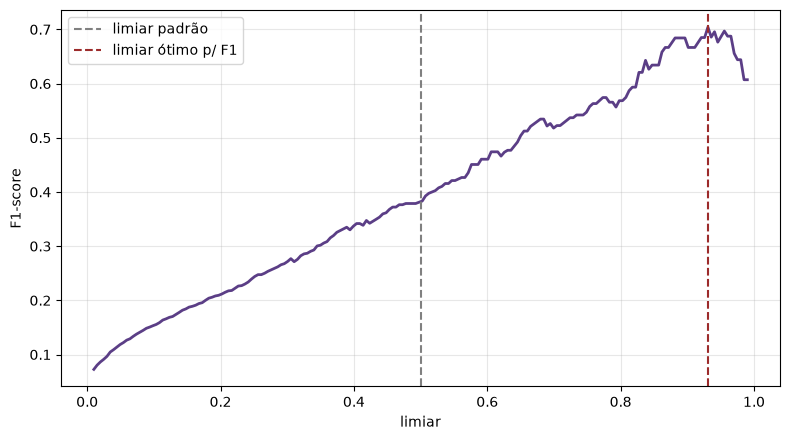

In [10]:
probs_over = modelo_over.predict_proba(X_teste)[:, 1]
limiares = np.linspace(0.01, 0.99, 200)
f1s = [f1_score(y_teste, (probs_over >= t).astype(int), zero_division=0) for t in limiares]

limiar_otimo_f1 = limiares[np.argmax(f1s)]
f1_otimo = max(f1s)
f1_padrao = f1_score(y_teste, (probs_over >= 0.5).astype(int))

print(f"F1 no limiar padrão (0,5)        : {f1_padrao:.4f}")
print(f"F1 no limiar ótimo ({limiar_otimo_f1:.3f})     : {f1_otimo:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(limiares, f1s, color=ROXO, lw=2)
ax.axvline(0.5, color="gray", ls="--", label="limiar padrão")
ax.axvline(limiar_otimo_f1, color=VERMELHO, ls="--", label="limiar ótimo p/ F1")
ax.set_xlabel("limiar"); ax.set_ylabel("F1-score")
ax.legend(); plt.tight_layout(); plt.show()

---
## Exercício 5 🔴 — Custo de negócio real: qual estratégia escolher?

Uma empresa estima: reter proativamente um cliente que iria mesmo ficar
(falso positivo) custa R\$ 50 (desconto/oferta desnecessária). Perder um
cliente que iria cancelar sem agir (falso negativo) custa R\$ 600 (o valor
do cliente perdido). Compare o custo total esperado de TRÊS estratégias no
conjunto de teste: (a) modelo sem correção com limiar 0,5; (b) modelo com
oversampling e limiar 0,5; (c) modelo sem correção, mas com o limiar de
custo ótimo. Qual delas você recomendaria?

In [11]:
# --- sua resposta ---

### Gabarito 5

In [12]:
CUSTO_FP, CUSTO_FN = 50, 600


def custo(y_real, pred):
    m = confusion_matrix(y_real, pred)
    fp, fn = m[0, 1], m[1, 0]
    return fp * CUSTO_FP + fn * CUSTO_FN


# (a) sem correção, limiar 0,5
custo_a = custo(y_teste, pred_simples)

# (b) oversampling, limiar 0,5
custo_b = custo(y_teste, pred_over)

# (c) sem correção, limiar de custo ótimo
custos_por_limiar = [custo(y_teste, (probs_simples >= t).astype(int)) for t in limiares]
limiar_otimo_custo = limiares[np.argmin(custos_por_limiar)]
custo_c = min(custos_por_limiar)

print(f"(a) sem correção, limiar 0,5           : R$ {custo_a:,.2f}")
print(f"(b) oversampling, limiar 0,5           : R$ {custo_b:,.2f}")
print(f"(c) sem correção, limiar ótimo ({limiar_otimo_custo:.3f}) : R$ {custo_c:,.2f}")

melhor = min([("a", custo_a), ("b", custo_b), ("c", custo_c)], key=lambda x: x[1])
print(f"\nmelhor estratégia: ({melhor[0]}), custo R$ {melhor[1]:,.2f}")

(a) sem correção, limiar 0,5           : R$ 9,850.00
(b) oversampling, limiar 0,5           : R$ 7,350.00
(c) sem correção, limiar ótimo (0.044) : R$ 5,500.00

melhor estratégia: (c), custo R$ 5,500.00


**Resposta esperada:** ajustar o limiar (estratégia c) costuma vencer ou
empatar com oversampling neste tipo de cenário — porque ambos, no fundo,
deslocam o ponto de operação na mesma curva precisão-recall subjacente, mas
o ajuste de limiar faz isso **sem custo de retreinamento** e de forma
diretamente calibrada ao custo real. Isso não significa que reamostragem
nunca ajuda: ela pode melhorar a qualidade do `predict_proba` em si (a
calibração e a separação entre classes), enquanto ajuste de limiar só
reposiciona o corte sobre probabilidades já calculadas. Na prática, as duas
técnicas costumam ser usadas juntas, não como substitutas uma da outra.

---
## Fechamento

- Acurácia é a métrica errada para escolher ou validar um modelo quando a
  classe positiva é rara — meça sempre contra o baseline "sempre a classe
  majoritária".
- PR-AUC reflete melhor a dificuldade real do problema que ROC-AUC quando
  há forte desbalanceamento.
- Reamostragem (over/undersampling, SMOTE) e pesos de classe atacam o
  treino; ajuste de limiar atacado a decisão final — são complementares.
- A escolha final de limiar (ou de estratégia) deveria refletir o custo real
  de cada tipo de erro, sempre que esse custo puder ser estimado.

→ Este é o fim do tema **Preparação de Dados**. A partir daqui, o tema 4
(Aprendizado Supervisionado) assume que os dados já chegam limpos,
transformados e com o desbalanceamento tratado — e foca na escolha e no
ajuste dos modelos em si.